# 🌸 Analisis BeritaWord Embedding Skip-gram vs CBOW pada Klasifikasi Berita (Sport vs Finance)

Notebook ini membandingkan **Skip-gram** dan **CBOW** dalam dua implementasi:

* **Manual** (NumPy, negative sampling), dan
* **Gensim** (`Word2Vec`).

Vektor kata dirata-rata per berita, lalu dievaluasi dengan **Naive Bayes** (akurasi dan F1). Tiga hal yang diuji:

1. **Skenario preprocessing**: angka (dibuang / dipertahankan) × stopword (dibuang / dipertahankan). Tanda baca selalu dibuang dan semua teks di-lowercase.
2. **Eksperimen dimensi vektor (`n`) dan ukuran window (`w`)**: pengaruhnya ke waktu training *dan* ke kualitas klasifikasi.
3. **Dua tingkat perbandingan**: Manual vs Gensim (validasi implementasi + waktu), dan Skip-gram vs CBOW (tiap skenario dan tiap konfigurasi `n`, `w`).

> **Catatan waktu jalan:** implementasi manual berjalan di CPU dengan NumPy, jadi seluruh notebook membutuhkan sekitar 15-30 menit tergantung mesin. Sebagian besar waktu ada di bagian eksperimen `n` dan `w`. Kalau ingin lebih cepat, kecilkan `EPOCHS` atau `N_GRID`/`W_GRID` di sel konfigurasi.

## Konfigurasi dan Import

Semua hyperparameter yang dipakai bersama diletakkan di satu tempat supaya perbandingan adil:

* `EPOCHS` sama untuk semua model. CBOW hanya melakukan satu update per posisi kata (Skip-gram melakukan satu per pasangan konteks), sehingga CBOW butuh epoch yang cukup agar tidak *underfit* pada data sekecil ini.
* `MIN_COUNT` membatasi vocabulary. Dengan hanya 200 berita, kata yang muncul 1-4 kali hampir tidak punya informasi statistik untuk dipelajari embedding, dan membuang kata-kata itu memperkecil matriks sehingga model manual tetap realistis dijalankan.
* Negative sampling (`NEG=5`, distribusi unigram^0.75) dipakai di kedua implementasi, sama seperti default Gensim (`hs=0`). `sample=0` dan `workers=1` di Gensim dipakai agar setara dengan versi manual (tanpa subsampling, satu thread).

In [1]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
import re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score
from gensim.models import Word2Vec      # pip install gensim

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

SEED      = 42
EPOCHS    = 20
MIN_COUNT = 5
NEG       = 5
BATCH     = 256
N_BASE, W_BASE = 50, 2                  # konfigurasi dasar untuk perbandingan skenario
N_GRID = [10, 50, 100]                  # dimensi vektor (n) untuk eksperimen
W_GRID = [1, 3, 5]                      # ukuran window (w) untuk eksperimen
CSV_PATH = "dataset_berita.csv"
CLEAN_BOILERPLATE = False               # True = buang sisa teks web (iklan, tag) sebelum preprocessing; lihat bagian 1

## 1. Load dan Eksplorasi Data

Dataset berisi 200 berita berlabel `sport` dan `finance`. Kita cek ukuran, keseimbangan kelas, dan panjang berita.

Ukuran data: (200, 3)


,id,isi_berita,label
0,1,Jakarta - Putri Kusuma Wardani percaya diri de...,sport
1,2,Jakarta - Mata Derrick Michael Xzavierro berbi...,sport
2,3,Jakarta - Marc Marquez masih harus beradaptasi...,sport



Distribusi label:
label
sport      100
finance    100
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
finance,100.0,345.6,187.5,16.0,229.0,331.0,414.2,1080.0
sport,100.0,345.8,113.5,22.0,276.8,313.5,409.2,753.0


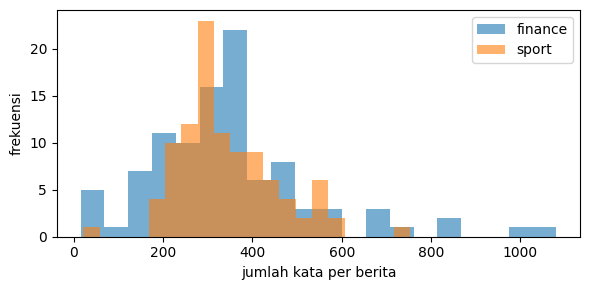

Berita yang memuat 'SCROLL TO CONTINUE WITH CONTENT': 193 dari 200
Berita yang memuat 'ADVERTISEMENT': 186 dari 200
Berita yang memuat 'Baca juga': 138 dari 200
Berita yang memuat 'Tautan telah disalin': 153 dari 200


In [3]:
df = pd.read_csv(CSV_PATH)
print("Ukuran data:", df.shape)
display(df.head(3))
print("\nDistribusi label:")
print(df["label"].value_counts())

df["n_kata"] = df["isi_berita"].str.split().str.len()
display(df.groupby("label")["n_kata"].describe().round(1))

fig, ax = plt.subplots(figsize=(6, 3))
for lab, g in df.groupby("label"):
    ax.hist(g["n_kata"], bins=20, alpha=0.6, label=lab)
ax.set_xlabel("jumlah kata per berita"); ax.set_ylabel("frekuensi"); ax.legend()
plt.tight_layout(); plt.show()

for pola in ["SCROLL TO CONTINUE WITH CONTENT", "ADVERTISEMENT", "Baca juga", "Tautan telah disalin"]:
    print(f"Berita yang memuat '{pola}': {df.isi_berita.str.contains(pola).sum()} dari {len(df)}")

**Temuan penting pada teks.** Banyak berita masih membawa sisa halaman web: `SCROLL TO CONTINUE WITH CONTENT`, `ADVERTISEMENT`, tautan `Baca juga`, dan, di akhir sebagian besar berita, deretan **tag/kata kunci editor** setelah `... Tautan telah disalin`. Tag itu (mis. `motogp`, `bank rakyat indonesia`) sangat spesifik topik, sehingga bisa membuat klasifikasi jauh lebih mudah dari yang seharusnya. Sesuai rencana awal, pembersihan ini **tidak** dilakukan secara default. Untuk mengujinya, set `CLEAN_BOILERPLATE = True` di sel konfigurasi (membuang penanda iklan dan semua teks setelah `... Tautan telah disalin`) dan jalankan ulang; bandingkan hasilnya.

Kelas seimbang (100 vs 100), sehingga akurasi cukup bermakna dan F1 macro akan bergerak searah dengan akurasi. Yang perlu diperhatikan: **data hanya 200 berita**, sehingga satu berita salah klasifikasi di test set (40 berita) sudah mengubah akurasi 2,5 poin. Karena itu selain split 80/20, kita juga memakai *stratified 5-fold cross-validation* di setiap evaluasi.

## 2. Fungsi Preprocessing

Langkah-langkahnya:

1. **Hapus dateline**: awalan seperti `Jakarta - ` di awal berita adalah pola redaksional, bukan isi. Regex yang dipakai juga menangkap kota lain (mis. `Nusa Dua - `) supaya tidak ada kata "jakarta" yang muncul di semua berita dan tidak informatif.
2. **Lowercase** supaya `Indonesia` dan `indonesia` dianggap satu kata.
3. **Buang tanda baca**: semua karakter selain huruf/angka diganti spasi (`Aichi-Nagoya` menjadi `aichi nagoya`).
4. **Buang angka** (opsional): token yang seluruhnya digit (`2026`, `19`). Token campuran seperti `u23` tetap dipertahankan.
5. **Buang stopword** (opsional): kata fungsi bahasa Indonesia yang sangat sering (`yang`, `dan`, `di`, ...). Daftarnya ditulis langsung di notebook agar tidak butuh unduhan NLTK/Sastrawi.

In [4]:
STOPWORDS = set("""yang dan di ke dari dalam untuk pada dengan ini itu atau juga karena sebagai adalah akan telah sudah masih belum
tidak bukan ada oleh saat sebuah para serta tetapi namun sehingga agar jika bila apabila ketika setelah sebelum sambil hingga sampai
antara terhadap tentang mengenai secara bagi lebih paling sangat hanya saja pun lah kah nya kami kita kamu anda saya aku dia mereka
beliau ia sini situ sana yaitu yakni yaitu dapat bisa harus perlu mau ingin akan sedang lagi kembali sekitar setiap semua seluruh
banyak beberapa berbagai lain lainnya tersebut begitu seperti sama dua tiga satu lalu kemudian sempat pernah tengah antara demi
bahwa mungkin dong deh sih tapi kalau ya oleh usai sejak selama bahkan tanpa kepada dalam atas bawah maka mana apa siapa
kapan bagaimana berapa mengapa mereka olehnya dirinya sendiri terus amat cukup kurang hampir kira""".split())

DATELINE = re.compile(r"^\s*[A-Z][A-Za-z\.\s]{1,30}?\s-\s")

def strip_dateline(t):
    return DATELINE.sub("", t, count=1)

def clean_boilerplate(t):
    t = t.split("... Tautan telah disalin")[0]           # tag/kata kunci editor di akhir berita
    return re.sub(r"SCROLL TO CONTINUE WITH CONTENT|ADVERTISEMENT", " ", t)

def preprocess(text, remove_numbers, remove_stopwords):
    if CLEAN_BOILERPLATE:
        text = clean_boilerplate(text)
    t = strip_dateline(text).lower()
    t = re.sub(r"[^a-z0-9\s]", " ", t)          # tanda baca selalu dibuang
    toks = t.split()
    if remove_numbers:
        toks = [w for w in toks if not w.isdigit()]
    if remove_stopwords:
        toks = [w for w in toks if w not in STOPWORDS]
    return toks

print("Berita pertama, sebelum dan sesudah strip dateline:")
print(" -", df.isi_berita[0][:90])
print(" -", strip_dateline(df.isi_berita[0])[:90])
print("Berita dengan dateline selain Jakarta dihapus juga:",
      df.isi_berita.str.extract(r"^([^-]{0,30}) - ")[0].nunique(), "dateline berbeda ditemukan")

Berita pertama, sebelum dan sesudah strip dateline:
 - Jakarta - Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBS
 - Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBSI untuk As
Berita dengan dateline selain Jakarta dihapus juga: 14 dateline berbeda ditemukan


## 3. Fungsi Bersama: Vocabulary, One-hot, Skip-gram/CBOW Manual, Gensim, Evaluasi

Bagian ini hanya mendefinisikan fungsi; tiap skenario di bawah memanggilnya.

**Tentang one-hot.** Input model adalah one-hot kata (vektor panjang `V` berisi satu angka 1). Perkalian `one_hot @ W_in` sama persis dengan mengambil satu baris `W_in[indeks]`. Agar training tidak membuat matriks `N × V` yang sangat besar, implementasi manual memakai bentuk *lookup* ini. Kesetaraannya dibuktikan (`np.allclose`) di sel one-hot tiap skenario.

**Model manual.**

* *Skip-gram*: input kata tengah, target kata-kata konteks di sekitarnya.
* *CBOW*: input rata-rata vektor kata konteks, target kata tengah.
* Keduanya memakai *negative sampling* dengan update mini-batch dan learning rate turun linear (0,025 ke 0,0001), sama seperti Gensim. Perbedaan yang tersisa: Gensim mengacak ukuran window per posisi (reduced window), sedangkan versi manual memakai window tetap; dan versi manual memakai mini-batch. Jadi hasil keduanya **mirip, bukan identik**.
* Waktu training manual mencakup pembuatan pasangan konteks dan seluruh epoch; waktu Gensim mencakup konstruktor `Word2Vec` (termasuk build vocab).

**Vektor berita** = rata-rata vektor input semua kata berita yang ada di vocabulary. **Evaluasi**: split 80/20 stratified (seed tetap, sama untuk semua model) ditambah 5-fold stratified CV. Embedding dilatih tanpa label pada seluruh 200 berita (tidak memakai informasi kelas), jadi tidak ada kebocoran label.

In [5]:
def build_vocab(docs, min_count):
    c = Counter(w for d in docs for w in d)
    words = [w for w, f in c.most_common() if f >= min_count]
    return words, {w: i for i, w in enumerate(words)}, np.array([c[w] for w in words], float)

def one_hot(idx, V):
    m = np.zeros((len(idx), V)); m[np.arange(len(idx)), idx] = 1
    return m

def encode_docs(docs, w2i):
    return [np.array([w2i[w] for w in d if w in w2i], dtype=np.int64) for d in docs]

def make_pairs(enc, w):
    toks = np.concatenate(enc); did = np.concatenate([np.full(len(e), i) for i,e in enumerate(enc)])
    N = len(toks); ctx = np.full((N, 2*w), -1, dtype=np.int64); col = 0
    for k in list(range(-w, 0)) + list(range(1, w+1)):
        i = np.arange(max(0,-k), min(N, N-k)); j = i + k
        ok = did[i] == did[j]
        ctx[i[ok], col] = toks[j[ok]]; col += 1
    return toks, ctx

def sigmoid(x): return 1/(1+np.exp(-np.clip(x,-30,30)))

def scatter_add(W, idx, vals):
    """W[idx[i]] += vals[i], dengan indeks duplikat dijumlahkan (lebih cepat dari np.add.at)."""
    idx = idx.ravel(); vals = vals.reshape(len(idx), -1)
    o = np.argsort(idx, kind='stable'); si = idx[o]
    starts = np.flatnonzero(np.r_[True, si[1:] != si[:-1]])
    W[si[starts]] += np.add.reduceat(vals[o], starts, axis=0)

def train_manual(kind, enc, freq, V, n, w, epochs=None, neg=None, lr0=0.025, lr_min=0.0001, batch=None, seed=None):
    epochs = epochs or EPOCHS; neg = neg or NEG; batch = batch or BATCH; seed = SEED if seed is None else seed
    t0 = time.perf_counter(); rng = np.random.default_rng(seed)
    toks, ctx = make_pairs(enc, w)
    if kind == 'sg':
        m = ctx >= 0; rows = np.repeat(np.arange(len(toks)), m.sum(1)); centers = toks[rows]; contexts = ctx[m]  # input=center, target=context
    W_in = (rng.random((V, n)) - 0.5) / n; W_out = np.zeros((V, n))
    p = freq**0.75; p /= p.sum()
    N = len(centers) if kind=='sg' else len(toks); total = epochs * ((N+batch-1)//batch); step = 0
    for ep in range(epochs):
        order = rng.permutation(N)
        for s in range(0, N, batch):
            b = order[s:s+batch]; lr = max(lr_min, lr0*(1-step/total)); step += 1
            negs = rng.choice(V, size=(len(b), neg), p=p)
            if kind == 'sg':
                inp = centers[b]; tgt = contexts[b]
                h = W_in[inp]
            else:
                c = ctx[b]; msk = (c >= 0); cnt = np.maximum(msk.sum(1), 1)
                h = (W_in[np.where(msk, c, 0)] * msk[:,:,None]).sum(1) / cnt[:,None]
                tgt = toks[b]
            up = W_out[tgt]; un = W_out[negs]
            gp = sigmoid((h*up).sum(1)) - 1; gn = sigmoid(np.einsum('bd,bkd->bk', h, un))
            gh = gp[:,None]*up + np.einsum('bk,bkd->bd', gn, un)
            scatter_add(W_out, np.concatenate([tgt, negs.ravel()]), np.concatenate([-lr*gp[:,None]*h, (-lr*gn[:,:,None]*h[:,None,:]).reshape(-1, h.shape[1])]))
            if kind == 'sg': scatter_add(W_in, inp, -lr*gh)
            else:
                gc = (-lr*gh)[:,None,:]*msk[:,:,None]
                scatter_add(W_in, c[msk], gc[msk])
    return W_in, time.perf_counter() - t0


def train_gensim(kind, docs, n, w, seed=None):
    t0 = time.perf_counter()
    m = Word2Vec(sentences=docs, vector_size=n, window=w, min_count=MIN_COUNT,
                 sg=1 if kind == "sg" else 0, hs=0, negative=NEG, sample=0,
                 alpha=0.025, min_alpha=0.0001, epochs=EPOCHS, workers=1,
                 seed=SEED if seed is None else seed)
    return list(m.wv.index_to_key), np.array(m.wv.vectors), time.perf_counter() - t0

def fit(kind, impl, docs, n, w):
    """Latih satu model. Return dict(words, matrix, time)."""
    if impl == "Manual":
        words, w2i, freq = build_vocab(docs, MIN_COUNT)
        W, t = train_manual(kind, encode_docs(docs, w2i), freq, len(words), n, w)
    else:
        words, W, t = train_gensim(kind, docs, n, w)
    return dict(words=words, matrix=W, time=t)

def doc_vectors(docs, model):
    w2i = {w: i for i, w in enumerate(model["words"])}
    out = np.zeros((len(docs), model["matrix"].shape[1]))
    for k, d in enumerate(docs):
        idx = [w2i[w] for w in d if w in w2i]
        if idx: out[k] = model["matrix"][idx].mean(axis=0)
    return out

### Label, one-hot label, dan split data

Label dikodekan `finance = 0`, `sport = 1`, lalu dibuat **one-hot** (`[1,0]` / `[0,1]`) sebagai representasi keluaran. `GaussianNB` di scikit-learn membutuhkan label **bulat** (0/1), bukan matriks one-hot, sehingga one-hot label diubah balik dengan `argmax` sebelum masuk ke classifier. Karena vektor kata bisa bernilai negatif, kita memakai **GaussianNB** (MultinomialNB menolak fitur negatif).

In [6]:
CLASSES = ["finance", "sport"]
y_raw = df["label"].map({c: i for i, c in enumerate(CLASSES)}).values
Y_onehot = one_hot(y_raw, len(CLASSES))
y = Y_onehot.argmax(axis=1)                       # label bulat untuk classifier
assert (y == y_raw).all()
print("Contoh one-hot label (5 pertama):\n", Y_onehot[:5].astype(int).tolist(), "-> argmax:", y[:5].tolist())

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, stratify=y, random_state=SEED)
print("Train:", len(idx_train), "| Test:", len(idx_test), "| proporsi sport di test:", y[idx_test].mean())

def evaluate(X):
    clf = GaussianNB().fit(X[idx_train], y[idx_train])
    pred = clf.predict(X[idx_test])
    cv = cross_validate(GaussianNB(), X, y, scoring=["accuracy", "f1_macro"],
                        cv=StratifiedKFold(5, shuffle=True, random_state=SEED))
    return dict(acc=accuracy_score(y[idx_test], pred), f1=f1_score(y[idx_test], pred, average="macro"),
                cv_acc=cv["test_accuracy"].mean(), cv_acc_std=cv["test_accuracy"].std(),
                cv_f1=cv["test_f1_macro"].mean())

RESULTS, MODELS, SC = [], {}, {}
MODEL_ORDER = [("sg", "Manual"), ("sg", "Gensim"), ("cbow", "Manual"), ("cbow", "Gensim")]
KIND_NAME = {"sg": "Skip-gram", "cbow": "CBOW"}

Contoh one-hot label (5 pertama):
 [[0, 1], [0, 1], [0, 1], [0, 1], [0, 1]] -> argmax: [1, 1, 1, 1, 1]
Train: 160 | Test: 40 | proporsi sport di test: 0.5


## Skenario 1: Angka dibuang, stopword dibuang

Angka **dibuang**, stopword **dibuang**. Tanda baca selalu dibuang dan teks di-lowercase.


### 1. 1 Preprocessing

In [7]:
SCN = "S1_angka_dibuang_stopword_dibuang"
docs = [preprocess(t, remove_numbers=True, remove_stopwords=True) for t in df.isi_berita]
SC[SCN] = dict(docs=docs)
words, w2i, freq = build_vocab(docs, MIN_COUNT)

print("Sebelum:", strip_dateline(df.isi_berita[0])[:200])
print("Sesudah:", " ".join(docs[0][:30]))
print(f"\nTotal token: {sum(map(len, docs)):,} | vocab penuh: {len(set(w for d in docs for w in d)):,} "
      f"| vocab (min_count={MIN_COUNT}): {len(words):,}")
print("10 kata teratas:", [(w, int(f)) for w, f in zip(words[:10], freq[:10])])

Sebelum: Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBSI untuk Asian Games 2026. Dia juga menyebut chemistry satu sama lain sudah klop. Bulutangkis Indonesia mengirimkan 20 wa
Sesudah: putri kusuma wardani percaya diri komposisi beregu putri dipilih pbsi asian games menyebut chemistry klop bulutangkis indonesia mengirimkan wakil tampil aichi nagoya september oktober mendatang atlet antaranya merupakan sektor beregu

Total token: 49,610 | vocab penuh: 7,491 | vocab (min_count=5): 2,203
10 kata teratas: [('indonesia', 387), ('menjadi', 284), ('baca', 266), ('video', 241), ('rp', 212), ('to', 204), ('scroll', 193), ('continue', 193), ('with', 193), ('content', 193)]


### 1.2 One-hot encoding

Vocabulary dibatasi `MIN_COUNT`. Di bawah ini one-hot untuk beberapa kata pertama sebuah berita (input model), lalu bukti bahwa `one_hot @ W` sama dengan lookup baris, dan one-hot label.

In [8]:
V = len(words)
sample_words = [w for w in docs[0] if w in w2i][:6]
sample_idx = np.array([w2i[w] for w in sample_words])
OH = one_hot(sample_idx, V)
print("Kata:", sample_words)
print("Bentuk one-hot:", OH.shape, "| indeks yang bernilai 1:", OH.argmax(1).tolist())

W_test = np.random.default_rng(0).normal(size=(V, 4))
print("one_hot @ W == W[indeks]  ->", np.allclose(OH @ W_test, W_test[sample_idx]))
print("One-hot label 3 berita pertama:", Y_onehot[:3].astype(int).tolist(), "->", CLASSES[y[0]], CLASSES[y[1]], CLASSES[y[2]])

Kata: ['putri', 'percaya', 'diri', 'beregu', 'putri', 'pbsi']
Bentuk one-hot: (6, 2203) | indeks yang bernilai 1: [380, 549, 209, 1169, 380, 1421]
one_hot @ W == W[indeks]  -> True
One-hot label 3 berita pertama: [[0, 1], [0, 1], [0, 1]] -> sport sport sport


### 1.3 Skip-gram (Manual dan Gensim)

Konfigurasi dasar: `n = 50` dimensi, `w = 2` window.

In [9]:
for impl in ["Manual", "Gensim"]:
    MODELS[(SCN, "sg", impl, N_BASE, W_BASE)] = m = fit("sg", impl, SC[SCN]["docs"], N_BASE, W_BASE)
    print(f"Skip-gram {impl:6s}: vocab={len(m['words'])}, waktu training={m['time']:.2f} s")

Skip-gram Manual: vocab=2203, waktu training=14.61 s
Skip-gram Gensim: vocab=2203, waktu training=1.70 s


### 1.4 CBOW (Manual dan Gensim)

In [10]:
for impl in ["Manual", "Gensim"]:
    MODELS[(SCN, "cbow", impl, N_BASE, W_BASE)] = m = fit("cbow", impl, SC[SCN]["docs"], N_BASE, W_BASE)
    print(f"CBOW {impl:6s}: vocab={len(m['words'])}, waktu training={m['time']:.2f} s")

CBOW Manual: vocab=2203, waktu training=5.69 s
CBOW Gensim: vocab=2203, waktu training=0.90 s


### 1.5 Naive Bayes dan evaluasi

Setiap model diubah menjadi vektor berita (rata-rata vektor kata), lalu dievaluasi dengan GaussianNB. `acc`/`f1` dari test 80/20; `cv_acc`/`cv_f1` dari 5-fold CV (lebih stabil untuk 200 data).

In [11]:
rows = []
for kind, impl in MODEL_ORDER:
    m = MODELS[(SCN, kind, impl, N_BASE, W_BASE)]
    r = evaluate(doc_vectors(SC[SCN]["docs"], m))
    rec = dict(fase="skenario", skenario=SCN, model=KIND_NAME[kind], impl=impl, n=N_BASE, w=W_BASE, waktu=m["time"], **r)
    RESULTS.append(rec); rows.append(rec)
display(pd.DataFrame(rows)[["model", "impl", "acc", "f1", "cv_acc", "cv_acc_std", "cv_f1", "waktu"]].round(4))

,model,impl,acc,f1,cv_acc,cv_acc_std,cv_f1,waktu
0,Skip-gram,Manual,1.000,1.000,0.975,0.0158,0.9750,14.6109
1,Skip-gram,Gensim,1.000,1.000,0.975,0.0158,0.9750,1.7041
2,CBOW,Manual,0.975,0.975,0.975,0.0158,0.9750,5.6907
3,CBOW,Gensim,0.925,0.925,0.940,0.0339,0.9399,0.9017


## Skenario 2: Angka dibuang, stopword dipertahankan

Angka **dibuang**, stopword **dipertahankan**. Tanda baca selalu dibuang dan teks di-lowercase.

### 2.1 Preprocessing

In [12]:
SCN = "S2_angka_dibuang_stopword_ada"
docs = [preprocess(t, remove_numbers=True, remove_stopwords=False) for t in df.isi_berita]
SC[SCN] = dict(docs=docs)
words, w2i, freq = build_vocab(docs, MIN_COUNT)

print("Sebelum:", strip_dateline(df.isi_berita[0])[:200])
print("Sesudah:", " ".join(docs[0][:30]))
print(f"\nTotal token: {sum(map(len, docs)):,} | vocab penuh: {len(set(w for d in docs for w in d)):,} "
      f"| vocab (min_count={MIN_COUNT}): {len(words):,}")
print("10 kata teratas:", [(w, int(f)) for w, f in zip(words[:10], freq[:10])])

Sebelum: Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBSI untuk Asian Games 2026. Dia juga menyebut chemistry satu sama lain sudah klop. Bulutangkis Indonesia mengirimkan 20 wa
Sesudah: putri kusuma wardani percaya diri dengan komposisi beregu putri yang dipilih pbsi untuk asian games dia juga menyebut chemistry satu sama lain sudah klop bulutangkis indonesia mengirimkan wakil untuk tampil

Total token: 67,367 | vocab penuh: 7,624 | vocab (min_count=5): 2,329
10 kata teratas: [('di', 1334), ('yang', 1270), ('dan', 1153), ('juga', 704), ('ini', 703), ('untuk', 645), ('dari', 584), ('dengan', 574), ('dalam', 468), ('itu', 422)]


### 2.2 One-hot encoding

Vocabulary dibatasi `MIN_COUNT`. Di bawah ini one-hot untuk beberapa kata pertama sebuah berita (input model), lalu bukti bahwa `one_hot @ W` sama dengan lookup baris, dan one-hot label.

In [13]:
V = len(words)
sample_words = [w for w in docs[0] if w in w2i][:6]
sample_idx = np.array([w2i[w] for w in sample_words])
OH = one_hot(sample_idx, V)
print("Kata:", sample_words)
print("Bentuk one-hot:", OH.shape, "| indeks yang bernilai 1:", OH.argmax(1).tolist())

W_test = np.random.default_rng(0).normal(size=(V, 4))
print("one_hot @ W == W[indeks]  ->", np.allclose(OH @ W_test, W_test[sample_idx]))
print("One-hot label 3 berita pertama:", Y_onehot[:3].astype(int).tolist(), "->", CLASSES[y[0]], CLASSES[y[1]], CLASSES[y[2]])

Kata: ['putri', 'percaya', 'diri', 'dengan', 'beregu', 'putri']
Bentuk one-hot: (6, 2329) | indeks yang bernilai 1: [483, 661, 296, 7, 1291, 483]
one_hot @ W == W[indeks]  -> True
One-hot label 3 berita pertama: [[0, 1], [0, 1], [0, 1]] -> sport sport sport


### 2.3 Skip-gram (Manual dan Gensim)

Konfigurasi dasar: `n = 50` dimensi, `w = 2` window.

In [14]:
for impl in ["Manual", "Gensim"]:
    MODELS[(SCN, "sg", impl, N_BASE, W_BASE)] = m = fit("sg", impl, SC[SCN]["docs"], N_BASE, W_BASE)
    print(f"Skip-gram {impl:6s}: vocab={len(m['words'])}, waktu training={m['time']:.2f} s")

Skip-gram Manual: vocab=2329, waktu training=20.63 s
Skip-gram Gensim: vocab=2329, waktu training=2.39 s


### 2.4 CBOW (Manual dan Gensim)

In [15]:
for impl in ["Manual", "Gensim"]:
    MODELS[(SCN, "cbow", impl, N_BASE, W_BASE)] = m = fit("cbow", impl, SC[SCN]["docs"], N_BASE, W_BASE)
    print(f"CBOW {impl:6s}: vocab={len(m['words'])}, waktu training={m['time']:.2f} s")

CBOW Manual: vocab=2329, waktu training=8.41 s
CBOW Gensim: vocab=2329, waktu training=1.25 s


### 2.5 Naive Bayes dan evaluasi

Setiap model diubah menjadi vektor berita (rata-rata vektor kata), lalu dievaluasi dengan GaussianNB. `acc`/`f1` dari test 80/20; `cv_acc`/`cv_f1` dari 5-fold CV (lebih stabil untuk 200 data).

In [16]:
rows = []
for kind, impl in MODEL_ORDER:
    m = MODELS[(SCN, kind, impl, N_BASE, W_BASE)]
    r = evaluate(doc_vectors(SC[SCN]["docs"], m))
    rec = dict(fase="skenario", skenario=SCN, model=KIND_NAME[kind], impl=impl, n=N_BASE, w=W_BASE, waktu=m["time"], **r)
    RESULTS.append(rec); rows.append(rec)
display(pd.DataFrame(rows)[["model", "impl", "acc", "f1", "cv_acc", "cv_acc_std", "cv_f1", "waktu"]].round(4))

,model,impl,acc,f1,cv_acc,cv_acc_std,cv_f1,waktu
0,Skip-gram,Manual,1.000,1.0000,0.975,0.0158,0.9750,20.6285
1,Skip-gram,Gensim,0.975,0.9750,0.955,0.0332,0.9549,2.3861
2,CBOW,Manual,0.975,0.9750,0.950,0.0354,0.9498,8.4112
3,CBOW,Gensim,0.900,0.8997,0.930,0.0430,0.9298,1.2547


## Skenario 3: Angka dipertahankan, stopword dibuang

Angka **dipertahankan**, stopword **dibuang**. Tanda baca selalu dibuang dan teks di-lowercase.

### 3.1 Preprocessing

In [17]:
SCN = "S3_angka_ada_stopword_dibuang"
docs = [preprocess(t, remove_numbers=False, remove_stopwords=True) for t in df.isi_berita]
SC[SCN] = dict(docs=docs)
words, w2i, freq = build_vocab(docs, MIN_COUNT)

print("Sebelum:", strip_dateline(df.isi_berita[0])[:200])
print("Sesudah:", " ".join(docs[0][:30]))
print(f"\nTotal token: {sum(map(len, docs)):,} | vocab penuh: {len(set(w for d in docs for w in d)):,} "
      f"| vocab (min_count={MIN_COUNT}): {len(words):,}")
print("10 kata teratas:", [(w, int(f)) for w, f in zip(words[:10], freq[:10])])

Sebelum: Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBSI untuk Asian Games 2026. Dia juga menyebut chemistry satu sama lain sudah klop. Bulutangkis Indonesia mengirimkan 20 wa
Sesudah: putri kusuma wardani percaya diri komposisi beregu putri dipilih pbsi asian games 2026 menyebut chemistry klop bulutangkis indonesia mengirimkan 20 wakil tampil aichi nagoya 19 september 4 oktober mendatang 10

Total token: 53,075 | vocab penuh: 7,832 | vocab (min_count=5): 2,285
10 kata teratas: [('2026', 522), ('indonesia', 387), ('9', 299), ('menjadi', 284), ('baca', 266), ('video', 241), ('rp', 212), ('to', 204), ('scroll', 193), ('continue', 193)]


### 3.2 One-hot encoding

Vocabulary dibatasi `MIN_COUNT`. Di bawah ini one-hot untuk beberapa kata pertama sebuah berita (input model), lalu bukti bahwa `one_hot @ W` sama dengan lookup baris, dan one-hot label.

In [18]:
V = len(words)
sample_words = [w for w in docs[0] if w in w2i][:6]
sample_idx = np.array([w2i[w] for w in sample_words])
OH = one_hot(sample_idx, V)
print("Kata:", sample_words)
print("Bentuk one-hot:", OH.shape, "| indeks yang bernilai 1:", OH.argmax(1).tolist())

W_test = np.random.default_rng(0).normal(size=(V, 4))
print("one_hot @ W == W[indeks]  ->", np.allclose(OH @ W_test, W_test[sample_idx]))
print("One-hot label 3 berita pertama:", Y_onehot[:3].astype(int).tolist(), "->", CLASSES[y[0]], CLASSES[y[1]], CLASSES[y[2]])

Kata: ['putri', 'percaya', 'diri', 'beregu', 'putri', 'pbsi']
Bentuk one-hot: (6, 2285) | indeks yang bernilai 1: [408, 583, 230, 1221, 408, 1475]
one_hot @ W == W[indeks]  -> True
One-hot label 3 berita pertama: [[0, 1], [0, 1], [0, 1]] -> sport sport sport


### 3.3 Skip-gram (Manual dan Gensim)

Konfigurasi dasar: `n = 50` dimensi, `w = 2` window.

In [19]:
for impl in ["Manual", "Gensim"]:
    MODELS[(SCN, "sg", impl, N_BASE, W_BASE)] = m = fit("sg", impl, SC[SCN]["docs"], N_BASE, W_BASE)
    print(f"Skip-gram {impl:6s}: vocab={len(m['words'])}, waktu training={m['time']:.2f} s")

Skip-gram Manual: vocab=2285, waktu training=15.73 s
Skip-gram Gensim: vocab=2285, waktu training=1.85 s


### 3.4 CBOW (Manual dan Gensim)

In [20]:
for impl in ["Manual", "Gensim"]:
    MODELS[(SCN, "cbow", impl, N_BASE, W_BASE)] = m = fit("cbow", impl, SC[SCN]["docs"], N_BASE, W_BASE)
    print(f"CBOW {impl:6s}: vocab={len(m['words'])}, waktu training={m['time']:.2f} s")

CBOW Manual: vocab=2285, waktu training=6.01 s
CBOW Gensim: vocab=2285, waktu training=0.97 s


### 3.5 Naive Bayes dan evaluasi

Setiap model diubah menjadi vektor berita (rata-rata vektor kata), lalu dievaluasi dengan GaussianNB. `acc`/`f1` dari test 80/20; `cv_acc`/`cv_f1` dari 5-fold CV (lebih stabil untuk 200 data).

In [21]:
rows = []
for kind, impl in MODEL_ORDER:
    m = MODELS[(SCN, kind, impl, N_BASE, W_BASE)]
    r = evaluate(doc_vectors(SC[SCN]["docs"], m))
    rec = dict(fase="skenario", skenario=SCN, model=KIND_NAME[kind], impl=impl, n=N_BASE, w=W_BASE, waktu=m["time"], **r)
    RESULTS.append(rec); rows.append(rec)
display(pd.DataFrame(rows)[["model", "impl", "acc", "f1", "cv_acc", "cv_acc_std", "cv_f1", "waktu"]].round(4))

,model,impl,acc,f1,cv_acc,cv_acc_std,cv_f1,waktu
0,Skip-gram,Manual,1.000,1.0000,0.970,0.0245,0.9700,15.7290
1,Skip-gram,Gensim,0.925,0.9246,0.960,0.0255,0.9599,1.8513
2,CBOW,Manual,0.975,0.9750,0.975,0.0274,0.9750,6.0108
3,CBOW,Gensim,0.875,0.8743,0.935,0.0406,0.9349,0.9708


## Skenario 4: Angka dipertahankan, stopword dipertahankan

Angka **dipertahankan**, stopword **dipertahankan**. Tanda baca selalu dibuang dan teks di-lowercase.

### 4.1 Preprocessing

In [22]:
SCN = "S4_angka_ada_stopword_ada"
docs = [preprocess(t, remove_numbers=False, remove_stopwords=False) for t in df.isi_berita]
SC[SCN] = dict(docs=docs)
words, w2i, freq = build_vocab(docs, MIN_COUNT)

print("Sebelum:", strip_dateline(df.isi_berita[0])[:200])
print("Sesudah:", " ".join(docs[0][:30]))
print(f"\nTotal token: {sum(map(len, docs)):,} | vocab penuh: {len(set(w for d in docs for w in d)):,} "
      f"| vocab (min_count={MIN_COUNT}): {len(words):,}")
print("10 kata teratas:", [(w, int(f)) for w, f in zip(words[:10], freq[:10])])

Sebelum: Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBSI untuk Asian Games 2026. Dia juga menyebut chemistry satu sama lain sudah klop. Bulutangkis Indonesia mengirimkan 20 wa
Sesudah: putri kusuma wardani percaya diri dengan komposisi beregu putri yang dipilih pbsi untuk asian games 2026 dia juga menyebut chemistry satu sama lain sudah klop bulutangkis indonesia mengirimkan 20 wakil

Total token: 70,832 | vocab penuh: 7,965 | vocab (min_count=5): 2,411
10 kata teratas: [('di', 1334), ('yang', 1270), ('dan', 1153), ('juga', 704), ('ini', 703), ('untuk', 645), ('dari', 584), ('dengan', 574), ('2026', 522), ('dalam', 468)]


### 4.2 One-hot encoding

Vocabulary dibatasi `MIN_COUNT`. Di bawah ini one-hot untuk beberapa kata pertama sebuah berita (input model), lalu bukti bahwa `one_hot @ W` sama dengan lookup baris, dan one-hot label.

In [23]:
V = len(words)
sample_words = [w for w in docs[0] if w in w2i][:6]
sample_idx = np.array([w2i[w] for w in sample_words])
OH = one_hot(sample_idx, V)
print("Kata:", sample_words)
print("Bentuk one-hot:", OH.shape, "| indeks yang bernilai 1:", OH.argmax(1).tolist())

W_test = np.random.default_rng(0).normal(size=(V, 4))
print("one_hot @ W == W[indeks]  ->", np.allclose(OH @ W_test, W_test[sample_idx]))
print("One-hot label 3 berita pertama:", Y_onehot[:3].astype(int).tolist(), "->", CLASSES[y[0]], CLASSES[y[1]], CLASSES[y[2]])

Kata: ['putri', 'percaya', 'diri', 'dengan', 'beregu', 'putri']
Bentuk one-hot: (6, 2411) | indeks yang bernilai 1: [511, 695, 317, 7, 1343, 511]
one_hot @ W == W[indeks]  -> True
One-hot label 3 berita pertama: [[0, 1], [0, 1], [0, 1]] -> sport sport sport


### 4.3 Skip-gram (Manual dan Gensim)

Konfigurasi dasar: `n = 50` dimensi, `w = 2` window.

In [24]:
for impl in ["Manual", "Gensim"]:
    MODELS[(SCN, "sg", impl, N_BASE, W_BASE)] = m = fit("sg", impl, SC[SCN]["docs"], N_BASE, W_BASE)
    print(f"Skip-gram {impl:6s}: vocab={len(m['words'])}, waktu training={m['time']:.2f} s")

Skip-gram Manual: vocab=2411, waktu training=21.64 s
Skip-gram Gensim: vocab=2411, waktu training=2.53 s


### 4.4 CBOW (Manual dan Gensim)

In [25]:
for impl in ["Manual", "Gensim"]:
    MODELS[(SCN, "cbow", impl, N_BASE, W_BASE)] = m = fit("cbow", impl, SC[SCN]["docs"], N_BASE, W_BASE)
    print(f"CBOW {impl:6s}: vocab={len(m['words'])}, waktu training={m['time']:.2f} s")

CBOW Manual: vocab=2411, waktu training=9.10 s
CBOW Gensim: vocab=2411, waktu training=1.30 s


### 4.5 Naive Bayes dan evaluasi

Setiap model diubah menjadi vektor berita (rata-rata vektor kata), lalu dievaluasi dengan GaussianNB. `acc`/`f1` dari test 80/20; `cv_acc`/`cv_f1` dari 5-fold CV (lebih stabil untuk 200 data).

In [26]:
rows = []
for kind, impl in MODEL_ORDER:
    m = MODELS[(SCN, kind, impl, N_BASE, W_BASE)]
    r = evaluate(doc_vectors(SC[SCN]["docs"], m))
    rec = dict(fase="skenario", skenario=SCN, model=KIND_NAME[kind], impl=impl, n=N_BASE, w=W_BASE, waktu=m["time"], **r)
    RESULTS.append(rec); rows.append(rec)
display(pd.DataFrame(rows)[["model", "impl", "acc", "f1", "cv_acc", "cv_acc_std", "cv_f1", "waktu"]].round(4))

,model,impl,acc,f1,cv_acc,cv_acc_std,cv_f1,waktu
0,Skip-gram,Manual,0.950,0.9499,0.970,0.0187,0.9699,21.6387
1,Skip-gram,Gensim,0.925,0.9246,0.955,0.0292,0.9548,2.5296
2,CBOW,Manual,0.900,0.8997,0.925,0.0500,0.9249,9.0953
3,CBOW,Gensim,0.900,0.8997,0.920,0.0579,0.9199,1.3011


## 4. Ringkasan Empat Skenario

Tabel gabungan untuk melihat pengaruh angka dan stopword. Karena data kecil, bandingkan **`cv_acc` beserta `cv_acc_std`**: selisih yang lebih kecil dari satu simpangan baku sebaiknya tidak dianggap perbedaan nyata.

In [27]:
df_scn = pd.DataFrame([r for r in RESULTS if r["fase"] == "skenario"])
display(df_scn.pivot_table(index="skenario", columns=["model", "impl"], values="cv_acc").round(4))
display(df_scn.pivot_table(index="skenario", columns=["model", "impl"], values="waktu").round(2))

best = df_scn.groupby("skenario")["cv_acc"].mean().sort_values(ascending=False)
BEST_SCN = best.index[0]
print("Rata-rata cv_acc (empat model) per skenario:"); print(best.round(4))
print("\nSkenario terpilih untuk eksperimen n dan w:", BEST_SCN)

model                               CBOW        Skip-gram       
impl                              Gensim Manual    Gensim Manual
skenario                                                        
S1_angka_dibuang_stopword_dibuang  0.940  0.975     0.975  0.975
S2_angka_dibuang_stopword_ada      0.930  0.950     0.955  0.975
S3_angka_ada_stopword_dibuang      0.935  0.975     0.960  0.970
S4_angka_ada_stopword_ada          0.920  0.925     0.955  0.970

model                               CBOW        Skip-gram       
impl                              Gensim Manual    Gensim Manual
skenario                                                        
S1_angka_dibuang_stopword_dibuang   0.90   5.69      1.70  14.61
S2_angka_dibuang_stopword_ada       1.25   8.41      2.39  20.63
S3_angka_ada_stopword_dibuang       0.97   6.01      1.85  15.73
S4_angka_ada_stopword_ada           1.30   9.10      2.53  21.64

Rata-rata cv_acc (empat model) per skenario:
skenario
S1_angka_dibuang_stopword_dibuang    0.9662
S3_angka_ada_stopword_dibuang        0.9600
S2_angka_dibuang_stopword_ada        0.9525
S4_angka_ada_stopword_ada            0.9425
Name: cv_acc, dtype: float64

Skenario terpilih untuk eksperimen n dan w: S1_angka_dibuang_stopword_dibuang


## 5. Eksperimen Dimensi Vektor (`n`) dan Window (`w`)

Pada skenario dengan rata-rata `cv_acc` tertinggi (dipilih otomatis di atas), semua kombinasi `n` × `w` dilatih untuk **Skip-gram dan CBOW, Manual dan Gensim**. Untuk tiap kombinasi dicatat waktu training **dan** akurasi/F1 Naive Bayes, sehingga kita bisa melihat apakah vektor yang lebih besar atau window yang lebih lebar benar-benar memperbaiki klasifikasi, bukan hanya memperlambat training.

Catatan: konfigurasi dasar (`n=50`, `w=2`) tidak ada di grid `W_GRID` default, jadi hasilnya berasal dari sel ini, bukan dari bagian skenario.

In [28]:
docs_best = SC[BEST_SCN]["docs"]
for n in N_GRID:
    for w in W_GRID:
        for kind, impl in MODEL_ORDER:
            m = fit(kind, impl, docs_best, n, w)
            r = evaluate(doc_vectors(docs_best, m))
            RESULTS.append(dict(fase="grid", skenario=BEST_SCN, model=KIND_NAME[kind], impl=impl,
                                n=n, w=w, waktu=m["time"], **r))
        print(f"selesai n={n}, w={w}")
df_grid = pd.DataFrame([r for r in RESULTS if r["fase"] == "grid"])
display(df_grid[["model", "impl", "n", "w", "acc", "f1", "cv_acc", "cv_f1", "waktu"]].round(4).reset_index(drop=True))

selesai n=10, w=1
selesai n=10, w=3
selesai n=10, w=5
selesai n=50, w=1
selesai n=50, w=3
selesai n=50, w=5
selesai n=100, w=1
selesai n=100, w=3
selesai n=100, w=5


,model,impl,n,w,acc,f1,cv_acc,cv_f1,waktu
0,Skip-gram,Manual,10,1,0.975,0.9750,0.960,0.9598,3.4446
1,Skip-gram,Gensim,10,1,0.925,0.9250,0.950,0.9499,0.8505
2,CBOW,Manual,10,1,0.875,0.8743,0.920,0.9197,2.2232
3,CBOW,Gensim,10,1,0.950,0.9499,0.925,0.9247,0.6056
4,Skip-gram,Manual,10,3,1.000,1.0000,0.980,0.9800,10.9408
5,Skip-gram,Gensim,10,3,1.000,1.0000,0.970,0.9700,1.5577
6,CBOW,Manual,10,3,0.975,0.9750,0.975,0.9750,2.8839
7,CBOW,Gensim,10,3,0.925,0.9250,0.955,0.9549,0.7640
8,Skip-gram,Manual,10,5,1.000,1.0000,0.980,0.9800,17.8177
9,Skip-gram,Gensim,10,5,1.000,1.0000,0.990,0.9900,2.1573


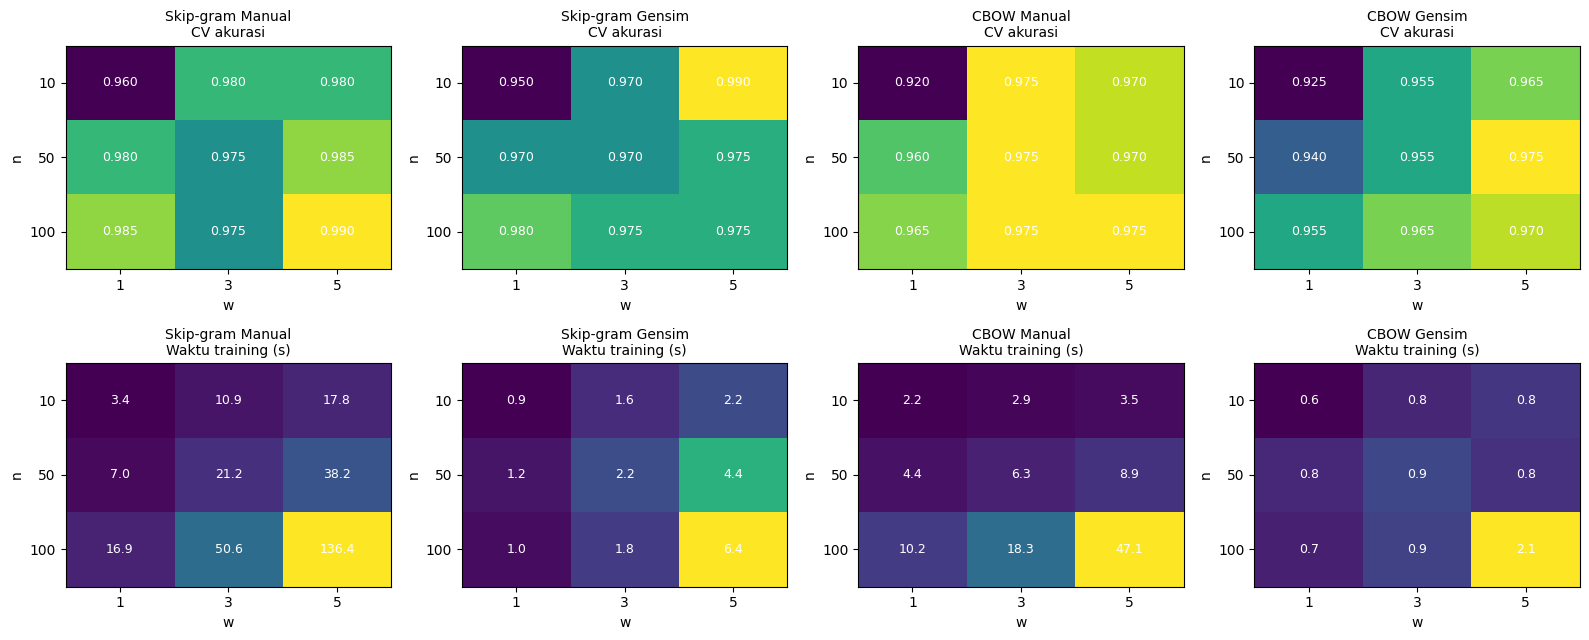

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
for j, (kind, impl) in enumerate(MODEL_ORDER):
    sub_df = df_grid[(df_grid.model == KIND_NAME[kind]) & (df_grid.impl == impl)]
    for i, (val, ttl, fmt) in enumerate([("cv_acc", "CV akurasi", ".3f"), ("waktu", "Waktu training (s)", ".1f")]):
        P = sub_df.pivot(index="n", columns="w", values=val)
        ax = axes[i, j]; im = ax.imshow(P.values, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(P.columns)), P.columns); ax.set_yticks(range(len(P.index)), P.index)
        ax.set_xlabel("w"); ax.set_ylabel("n"); ax.set_title(f"{KIND_NAME[kind]} {impl}\n{ttl}", fontsize=10)
        for a in range(P.shape[0]):
            for b in range(P.shape[1]):
                ax.text(b, a, format(P.values[a, b], fmt), ha="center", va="center", color="w", fontsize=9)
plt.tight_layout(); plt.show()

## 6. Perbandingan Akhir

### 6.1 Manual vs Gensim
Tujuan: (a) memeriksa apakah implementasi manual menghasilkan kualitas klasifikasi sebanding dengan Gensim, dan (b) membandingkan waktu training. Selisih akurasi positif berarti Manual lebih tinggi; rasio waktu > 1 berarti Manual lebih lambat.

In [30]:
df_all = pd.DataFrame(RESULTS)
def manual_vs_gensim(d):
    a = d[d.impl == "Manual"].set_index(["fase", "skenario", "model", "n", "w"])
    b = d[d.impl == "Gensim"].set_index(["fase", "skenario", "model", "n", "w"])
    out = pd.DataFrame({"acc_manual": a.acc, "acc_gensim": b.acc, "selisih_acc": a.acc - b.acc,
                        "cv_manual": a.cv_acc, "cv_gensim": b.cv_acc, "selisih_cv": a.cv_acc - b.cv_acc,
                        "f1_manual": a.f1, "f1_gensim": b.f1,
                        "waktu_manual": a.waktu, "waktu_gensim": b.waktu, "rasio_waktu": a.waktu / b.waktu})
    return out.reset_index()
mg = manual_vs_gensim(df_all)
print("Per skenario (n=%d, w=%d):" % (N_BASE, W_BASE))
display(mg[mg.fase == "skenario"].drop(columns="fase").round(4))
print("Per konfigurasi n dan w (skenario %s):" % BEST_SCN)
display(mg[mg.fase == "grid"].drop(columns=["fase", "skenario"]).round(4))
print("Rata-rata seluruh eksperimen:")
display(mg[["selisih_acc", "selisih_cv", "rasio_waktu"]].groupby(mg.model).mean().round(4))

Per skenario (n=50, w=2):


,skenario,model,n,w,acc_manual,acc_gensim,selisih_acc,cv_manual,cv_gensim,selisih_cv,f1_manual,f1_gensim,waktu_manual,waktu_gensim,rasio_waktu
0,S1_angka_dibuang_stopword_dibuang,Skip-gram,50,2,1.000,1.000,0.000,0.975,0.975,0.000,1.0000,1.0000,14.6109,1.7041,8.5741
1,S1_angka_dibuang_stopword_dibuang,CBOW,50,2,0.975,0.925,0.050,0.975,0.940,0.035,0.9750,0.9250,5.6907,0.9017,6.3112
2,S2_angka_dibuang_stopword_ada,Skip-gram,50,2,1.000,0.975,0.025,0.975,0.955,0.020,1.0000,0.9750,20.6285,2.3861,8.6454
3,S2_angka_dibuang_stopword_ada,CBOW,50,2,0.975,0.900,0.075,0.950,0.930,0.020,0.9750,0.8997,8.4112,1.2547,6.7035
4,S3_angka_ada_stopword_dibuang,Skip-gram,50,2,1.000,0.925,0.075,0.970,0.960,0.010,1.0000,0.9246,15.7290,1.8513,8.4963
5,S3_angka_ada_stopword_dibuang,CBOW,50,2,0.975,0.875,0.100,0.975,0.935,0.040,0.9750,0.8743,6.0108,0.9708,6.1917
6,S4_angka_ada_stopword_ada,Skip-gram,50,2,0.950,0.925,0.025,0.970,0.955,0.015,0.9499,0.9246,21.6387,2.5296,8.5544
7,S4_angka_ada_stopword_ada,CBOW,50,2,0.900,0.900,0.000,0.925,0.920,0.005,0.8997,0.8997,9.0953,1.3011,6.9904


Per konfigurasi n dan w (skenario S1_angka_dibuang_stopword_dibuang):


,model,n,w,acc_manual,acc_gensim,selisih_acc,cv_manual,cv_gensim,selisih_cv,f1_manual,f1_gensim,waktu_manual,waktu_gensim,rasio_waktu
8,Skip-gram,10,1,0.975,0.925,0.050,0.960,0.950,0.010,0.9750,0.9250,3.4446,0.8505,4.0499
9,CBOW,10,1,0.875,0.950,-0.075,0.920,0.925,-0.005,0.8743,0.9499,2.2232,0.6056,3.6710
10,Skip-gram,10,3,1.000,1.000,0.000,0.980,0.970,0.010,1.0000,1.0000,10.9408,1.5577,7.0239
11,CBOW,10,3,0.975,0.925,0.050,0.975,0.955,0.020,0.9750,0.9250,2.8839,0.7640,3.7746
12,Skip-gram,10,5,1.000,1.000,0.000,0.980,0.990,-0.010,1.0000,1.0000,17.8177,2.1573,8.2593
13,CBOW,10,5,0.975,0.950,0.025,0.970,0.965,0.005,0.9750,0.9500,3.5231,0.8383,4.2024
14,Skip-gram,50,1,1.000,1.000,0.000,0.980,0.970,0.010,1.0000,1.0000,7.0463,1.1716,6.0142
15,CBOW,50,1,0.925,0.925,0.000,0.960,0.940,0.020,0.9250,0.9250,4.3603,0.7690,5.6705
16,Skip-gram,50,3,1.000,1.000,0.000,0.975,0.970,0.005,1.0000,1.0000,21.1924,2.1728,9.7535
17,CBOW,50,3,0.975,0.950,0.025,0.975,0.955,0.020,0.9750,0.9500,6.2992,0.9270,6.7952


Rata-rata seluruh eksperimen:


,selisih_acc,selisih_cv,rasio_waktu
model,,,
CBOW,0.0231,0.0138,9.0951
Skip-gram,0.0115,0.0077,10.9929


### 6.2 Skip-gram vs CBOW
Dibandingkan pada implementasi yang sama, di setiap skenario dan setiap konfigurasi `n`, `w`. Selisih positif berarti Skip-gram lebih tinggi; rasio waktu > 1 berarti Skip-gram lebih lambat.

In [31]:
def sg_vs_cbow(d):
    idx = ["fase", "skenario", "impl", "n", "w"]
    a = d[d.model == "Skip-gram"].set_index(idx); b = d[d.model == "CBOW"].set_index(idx)
    out = pd.DataFrame({"acc_sg": a.acc, "acc_cbow": b.acc, "selisih_acc": a.acc - b.acc,
                        "cv_sg": a.cv_acc, "cv_cbow": b.cv_acc, "selisih_cv": a.cv_acc - b.cv_acc,
                        "f1_sg": a.f1, "f1_cbow": b.f1,
                        "waktu_sg": a.waktu, "waktu_cbow": b.waktu, "rasio_waktu": a.waktu / b.waktu})
    return out.reset_index()
sc = sg_vs_cbow(df_all)
print("Per skenario (n=%d, w=%d):" % (N_BASE, W_BASE))
display(sc[sc.fase == "skenario"].drop(columns="fase").round(4))
print("Per konfigurasi n dan w (skenario %s):" % BEST_SCN)
display(sc[sc.fase == "grid"].drop(columns=["fase", "skenario"]).round(4))

Per skenario (n=50, w=2):


,skenario,impl,n,w,acc_sg,acc_cbow,selisih_acc,cv_sg,cv_cbow,selisih_cv,f1_sg,f1_cbow,waktu_sg,waktu_cbow,rasio_waktu
0,S1_angka_dibuang_stopword_dibuang,Manual,50,2,1.000,0.975,0.025,0.975,0.975,0.000,1.0000,0.9750,14.6109,5.6907,2.5675
1,S1_angka_dibuang_stopword_dibuang,Gensim,50,2,1.000,0.925,0.075,0.975,0.940,0.035,1.0000,0.9250,1.7041,0.9017,1.8899
2,S2_angka_dibuang_stopword_ada,Manual,50,2,1.000,0.975,0.025,0.975,0.950,0.025,1.0000,0.9750,20.6285,8.4112,2.4525
3,S2_angka_dibuang_stopword_ada,Gensim,50,2,0.975,0.900,0.075,0.955,0.930,0.025,0.9750,0.8997,2.3861,1.2547,1.9016
4,S3_angka_ada_stopword_dibuang,Manual,50,2,1.000,0.975,0.025,0.970,0.975,-0.005,1.0000,0.9750,15.7290,6.0108,2.6168
5,S3_angka_ada_stopword_dibuang,Gensim,50,2,0.925,0.875,0.050,0.960,0.935,0.025,0.9246,0.8743,1.8513,0.9708,1.9070
6,S4_angka_ada_stopword_ada,Manual,50,2,0.950,0.900,0.050,0.970,0.925,0.045,0.9499,0.8997,21.6387,9.0953,2.3791
7,S4_angka_ada_stopword_ada,Gensim,50,2,0.925,0.900,0.025,0.955,0.920,0.035,0.9246,0.8997,2.5296,1.3011,1.9441


Per konfigurasi n dan w (skenario S1_angka_dibuang_stopword_dibuang):


,impl,n,w,acc_sg,acc_cbow,selisih_acc,cv_sg,cv_cbow,selisih_cv,f1_sg,f1_cbow,waktu_sg,waktu_cbow,rasio_waktu
8,Manual,10,1,0.975,0.875,0.100,0.960,0.920,0.040,0.975,0.8743,3.4446,2.2232,1.5494
9,Gensim,10,1,0.925,0.950,-0.025,0.950,0.925,0.025,0.925,0.9499,0.8505,0.6056,1.4044
10,Manual,10,3,1.000,0.975,0.025,0.980,0.975,0.005,1.000,0.9750,10.9408,2.8839,3.7938
11,Gensim,10,3,1.000,0.925,0.075,0.970,0.955,0.015,1.000,0.9250,1.5577,0.7640,2.0388
12,Manual,10,5,1.000,0.975,0.025,0.980,0.970,0.010,1.000,0.9750,17.8177,3.5231,5.0575
13,Gensim,10,5,1.000,0.950,0.050,0.990,0.965,0.025,1.000,0.9500,2.1573,0.8383,2.5733
14,Manual,50,1,1.000,0.925,0.075,0.980,0.960,0.020,1.000,0.9250,7.0463,4.3603,1.6160
15,Gensim,50,1,1.000,0.925,0.075,0.970,0.940,0.030,1.000,0.9250,1.1716,0.7690,1.5236
16,Manual,50,3,1.000,0.975,0.025,0.975,0.975,0.000,1.000,0.9750,21.1924,6.2992,3.3643
17,Gensim,50,3,1.000,0.950,0.050,0.970,0.955,0.015,1.000,0.9500,2.1728,0.9270,2.3439


### 6.3 Tabel akhir gabungan
Akurasi, F1, dan waktu training untuk semua model pada semua skenario (konfigurasi dasar).

In [32]:
final = df_all[df_all.fase == "skenario"].pivot_table(index="skenario", columns=["model", "impl"],
                                                      values=["acc", "f1", "cv_acc", "waktu"])
final = final.swaplevel(0, 1, axis=1).sort_index(axis=1)
display(final.round(4))

model                               CBOW                                                      Skip-gram                                                      
                                     acc        cv_acc             f1           waktu               acc        cv_acc             f1           waktu         
impl                              Gensim Manual Gensim Manual  Gensim  Manual  Gensim  Manual    Gensim Manual Gensim Manual  Gensim  Manual  Gensim   Manual
skenario                                                                                                                                                     
S1_angka_dibuang_stopword_dibuang  0.925  0.975  0.940  0.975  0.9250  0.9750  0.9017  5.6907     1.000   1.00  0.975  0.975  1.0000  1.0000  1.7041  14.6109
S2_angka_dibuang_stopword_ada      0.900  0.975  0.930  0.950  0.8997  0.9750  1.2547  8.4112     0.975   1.00  0.955  0.975  0.9750  1.0000  2.3861  20.6285
S3_angka_ada_stopword_dibuang      0.875  0.975  0.935  0.975  0.8743  0.9750  0.9708  6.0108     0.925   1.00  0.960  0.970  0.9246  1.0000  1.8513  15.7290
S4_angka_ada_stopword_ada          0.900  0.900  0.920  0.925  0.8997  0.8997  1.3011  9.0953     0.925   0.95  0.955  0.970  0.9246  0.9499  2.5296  21.6387

## 7.Rangkuman Hasil Eksperimen

Eksperimen dilakukan menggunakan **Word2Vec** dengan dua metode, yaitu **Skip-gram dan CBOW**, serta dua implementasi, yaitu **Manual menggunakan NumPy dan Gensim**. Hasil word embedding kemudian digunakan sebagai input untuk **Gaussian Naive Bayes** dalam mengklasifikasikan berita menjadi **sport** dan **finance**.

### 1. Skenario 1 — Angka Dibuang, Stopword Dibuang

Pada Skenario 1, angka dan stopword dihapus dari teks.

| Metode    | Implementasi | Akurasi Test | CV Accuracy | F1-Score |
| --------- | ------------ | -----------: | ----------: | -------: |
| Skip-gram | Manual       |         100% |       97,5% |     100% |
| Skip-gram | Gensim       |         100% |       97,5% |     100% |
| CBOW      | Manual       |        97,5% |       97,5% |    97,5% |
| CBOW      | Gensim       |        92,5% |       94,0% |    92,5% |

Skenario 1 menghasilkan **rata-rata CV Accuracy sebesar 96,62%**. Pada skenario ini, Skip-gram Manual dan Gensim memiliki CV Accuracy yang sama, yaitu 97,5%. CBOW Manual juga memperoleh 97,5%, sedangkan CBOW Gensim memperoleh 94%.

---

### 2. Skenario 2 — Angka Dibuang, Stopword Dipertahankan

Pada Skenario 2, angka dihapus tetapi stopword tetap dipertahankan.

| Metode    | Implementasi | Akurasi Test | CV Accuracy | F1-Score |
| --------- | ------------ | -----------: | ----------: | -------: |
| Skip-gram | Manual       |         100% |       97,5% |     100% |
| Skip-gram | Gensim       |        97,5% |       95,5% |    97,5% |
| CBOW      | Manual       |        97,5% |       95,0% |    97,5% |
| CBOW      | Gensim       |          90% |       93,0% |   89,97% |

Skenario 2 menghasilkan **rata-rata CV Accuracy sebesar 95,25%**. Skip-gram Manual memperoleh CV Accuracy tertinggi pada skenario ini, yaitu 97,5%.

Dibandingkan Skenario 1, performa rata-rata mengalami penurunan. Hal ini menunjukkan bahwa mempertahankan stopword pada dataset ini menghasilkan representasi yang sedikit kurang optimal untuk klasifikasi.

---

### 3. Skenario 3 — Angka Dipertahankan, Stopword Dibuang

Pada Skenario 3, angka tetap digunakan, sedangkan stopword dihapus.

| Metode    | Implementasi | Akurasi Test | CV Accuracy | F1-Score |
| --------- | ------------ | -----------: | ----------: | -------: |
| Skip-gram | Manual       |         100% |       97,0% |     100% |
| Skip-gram | Gensim       |        92,5% |       96,0% |   92,46% |
| CBOW      | Manual       |        97,5% |       97,5% |    97,5% |
| CBOW      | Gensim       |        87,5% |       93,5% |   87,43% |

Skenario 3 menghasilkan **rata-rata CV Accuracy sebesar 96,00%**.

Pada skenario ini, CBOW Manual memperoleh CV Accuracy sebesar 97,5%, sedangkan Skip-gram Manual memperoleh 97,0%. Implementasi Gensim memperoleh 96,0% untuk Skip-gram dan 93,5% untuk CBOW.

---

### 4. Skenario 4 — Angka Dipertahankan, Stopword Dipertahankan

Pada Skenario 4, angka dan stopword sama-sama dipertahankan.

| Metode    | Implementasi | Akurasi Test | CV Accuracy | F1-Score |
| --------- | ------------ | -----------: | ----------: | -------: |
| Skip-gram | Manual       |          95% |       97,0% |   94,99% |
| Skip-gram | Gensim       |        92,5% |       95,5% |   92,46% |
| CBOW      | Manual       |          90% |       92,5% |   89,97% |
| CBOW      | Gensim       |          90% |       92,0% |   89,97% |

Skenario 4 menghasilkan **rata-rata CV Accuracy sebesar 94,25%**, yang merupakan rata-rata terendah dari keempat skenario.

---

## Perbandingan Rata-rata Setiap Skenario

| Skenario | Preprocessing                                | Rata-rata CV Accuracy |
| -------- | -------------------------------------------- | --------------------: |
| **S1**   | Angka dibuang + stopword dibuang             |            **96,62%** |
| **S3**   | Angka dipertahankan + stopword dibuang       |            **96,00%** |
| **S2**   | Angka dibuang + stopword dipertahankan       |            **95,25%** |
| **S4**   | Angka dipertahankan + stopword dipertahankan |            **94,25%** |

Berdasarkan rata-rata CV Accuracy, Skenario 1 menghasilkan nilai tertinggi, yaitu **96,62%**.

---

## Perbandingan Manual dan Gensim

Pada seluruh eksperimen skenario, implementasi **Manual** dan **Gensim** juga dibandingkan.

Pada pengujian skenario dengan `n=50` dan `w=2`, hasilnya menunjukkan:

* Pada **Skip-gram**, Manual dan Gensim memiliki hasil yang sama pada S1, sedangkan pada S2, S3, dan S4 Manual memiliki CV Accuracy lebih tinggi.
* Pada **CBOW**, Manual memiliki CV Accuracy lebih tinggi daripada Gensim pada S1, S2, S3, dan S4.
* Secara keseluruhan, rata-rata selisih CV Accuracy **Manual − Gensim adalah +0,0108**.
* Dari sisi waktu pelatihan, **Gensim jauh lebih cepat** dibandingkan implementasi Manual. Rata-rata waktu Manual sekitar **11,7 kali** waktu Gensim pada seluruh eksperimen.

Dengan demikian, hasil eksperimen menunjukkan adanya perbedaan antara kedua implementasi, terutama dari sisi waktu komputasi.

---

## Perbandingan Skip-gram dan CBOW

Eksperimen juga membandingkan metode **Skip-gram** dan **CBOW**.

Pada seluruh eksperimen grid, Skip-gram memiliki CV Accuracy lebih tinggi daripada CBOW pada **21 dari 26 perbandingan**, sama pada 4 perbandingan, dan lebih rendah pada 1 perbandingan.

Rata-rata selisih CV Accuracy antara Skip-gram dan CBOW adalah:

**Skip-gram − CBOW = +0,0177**

Artinya, berdasarkan keseluruhan hasil eksperimen pada notebook, Skip-gram menghasilkan CV Accuracy rata-rata sekitar **1,77 poin persentase lebih tinggi** daripada CBOW.

---

## Pengujian Dimensi Vektor dan Window

Setelah Skenario 1 dipilih, dilakukan eksperimen terhadap ukuran dimensi vektor (`n`) dan ukuran window (`w`).

### Pengaruh Dimensi Vektor

| Dimensi Vektor (`n`) | Rata-rata CV Accuracy |
| -------------------: | --------------------: |
|                   10 |                96,17% |
|                   50 |                96,92% |
|                  100 |            **97,38%** |

Berdasarkan rata-rata seluruh model, dimensi vektor **100** menghasilkan rata-rata CV Accuracy tertinggi.

### Pengaruh Window

| Window (`w`) | Rata-rata CV Accuracy |
| -----------: | --------------------: |
|            1 |                95,75% |
|            3 |                97,04% |
|            5 |            **97,67%** |

Berdasarkan hasil tersebut, window **5** menghasilkan rata-rata CV Accuracy tertinggi.

---

## Konfigurasi Terbaik

Dari seluruh pengujian kombinasi dimensi vektor dan window pada Skenario 1, konfigurasi dengan CV Accuracy tertinggi adalah:

* **Metode:** Skip-gram
* **Implementasi:** Gensim
* **Dimensi vektor (`n`):** 10
* **Window (`w`):** 5
* **CV Accuracy:** **99,0%**
* **Waktu:** sekitar **2,1 detik**

---

## Kesimpulan

Berdasarkan seluruh eksperimen, preprocessing **Skenario 1**, yaitu **membuang angka dan stopword**, menghasilkan rata-rata CV Accuracy tertinggi di antara empat skenario preprocessing, yaitu **96,62%**.

Pada perbandingan metode Word2Vec, **Skip-gram memiliki rata-rata CV Accuracy lebih tinggi daripada CBOW** pada keseluruhan eksperimen. Sementara itu, implementasi **Gensim memiliki waktu pelatihan yang jauh lebih cepat dibandingkan implementasi Manual**, meskipun nilai akurasinya dapat berbeda pada beberapa konfigurasi.

Pada pengujian parameter, peningkatan dimensi vektor dari 10 ke 50 dan 100 menghasilkan rata-rata CV Accuracy yang lebih tinggi. Demikian pula, peningkatan ukuran window dari 1 ke 3 dan 5 menghasilkan rata-rata CV Accuracy yang lebih tinggi.

Konfigurasi dengan hasil CV Accuracy tertinggi dalam grid eksperimen adalah **Skip-gram Gensim dengan dimensi vektor 10 dan window 5**, yang memperoleh **CV Accuracy sebesar 99,0%**.

Secara keseluruhan, eksperimen menunjukkan bahwa hasil klasifikasi dipengaruhi oleh **preprocessing, metode Word2Vec, implementasi, dimensi vektor, dan ukuran window**. Pada dataset berita yang digunakan, kombinasi parameter dan preprocessing tertentu dapat menghasilkan performa klasifikasi yang lebih tinggi dibandingkan konfigurasi lainnya.


In [33]:
gs = df_all[df_all.fase == "grid"]
print("=== Ringkasan otomatis ===")
print(f"Skenario terbaik (rata-rata cv_acc): {BEST_SCN}")
rng_sc = df_scn.groupby("skenario")["cv_acc"].mean()
print(f"Rentang cv_acc antar-skenario: {rng_sc.min():.4f} - {rng_sc.max():.4f} "
      f"(simpangan baku CV tipikal: {df_scn.cv_acc_std.mean():.4f})")

top = gs.sort_values(["cv_acc", "waktu"], ascending=[False, True]).iloc[0]
print(f"Konfigurasi grid terbaik: {top.model} {top.impl}, n={top.n}, w={top.w}, cv_acc={top.cv_acc:.4f}, waktu={top.waktu:.1f}s")

print("\nManual vs Gensim (seluruh eksperimen):")
print(f"  rata-rata selisih cv_acc (Manual - Gensim): {mg.selisih_cv.mean():+.4f}")
print(f"  Manual rata-rata {mg.rasio_waktu.mean():.1f}x waktu Gensim")

print("\nSkip-gram vs CBOW (seluruh eksperimen):")
print(f"  Skip-gram lebih tinggi pada cv_acc di {(sc.selisih_cv > 0).sum()} dari {len(sc)} perbandingan, "
      f"sama di {(sc.selisih_cv == 0).sum()}, lebih rendah di {(sc.selisih_cv < 0).sum()}")
print(f"  rata-rata selisih cv_acc (SG - CBOW): {sc.selisih_cv.mean():+.4f}")
print(f"  Skip-gram rata-rata {sc.rasio_waktu.mean():.1f}x waktu CBOW")

print("\nPengaruh n (rata-rata cv_acc, semua model):"); print(gs.groupby("n")[["cv_acc", "waktu"]].mean().round(4))
print("\nPengaruh w (rata-rata cv_acc, semua model):"); print(gs.groupby("w")[["cv_acc", "waktu"]].mean().round(4))

=== Ringkasan otomatis ===
Skenario terbaik (rata-rata cv_acc): S1_angka_dibuang_stopword_dibuang
Rentang cv_acc antar-skenario: 0.9425 - 0.9663 (simpangan baku CV tipikal: 0.0302)
Konfigurasi grid terbaik: Skip-gram Gensim, n=10, w=5, cv_acc=0.9900, waktu=2.2s

Manual vs Gensim (seluruh eksperimen):
  rata-rata selisih cv_acc (Manual - Gensim): +0.0108
  Manual rata-rata 10.0x waktu Gensim

Skip-gram vs CBOW (seluruh eksperimen):
  Skip-gram lebih tinggi pada cv_acc di 21 dari 26 perbandingan, sama di 4, lebih rendah di 1
  rata-rata selisih cv_acc (SG - CBOW): +0.0177
  Skip-gram rata-rata 2.6x waktu CBOW

Pengaruh n (rata-rata cv_acc, semua model):
     cv_acc    waktu
n                   
10   0.9617   3.9672
50   0.9692   8.0195
100  0.9738  24.3733

Pengaruh w (rata-rata cv_acc, semua model):
   cv_acc    waktu
w                 
1  0.9575   4.1092
3  0.9704   9.8678
5  0.9767  22.3831
